CELL 1 — Setup & Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats

# Sklearn utilities
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option("display.max_columns", 200)
sns.set(style="whitegrid")

print("Libraries loaded successfully.")


Libraries loaded successfully.


CELL 2 — Load Dataset

In [2]:
data_path = "../data/PhiUSIIL_Phishing_URL_Dataset.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully.")
else:
    raise FileNotFoundError(f"Dataset not found at {data_path}")

print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


CELL 3 - Basic Dataset Overview

In [3]:
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nUnique Values:")
print(df.nunique().sort_values(ascending=False))



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13 

CELL 4 — Target Variable Analysis


Target Distribution:
label
1    134850
0    100945
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_22164\3927344617.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="Set2")


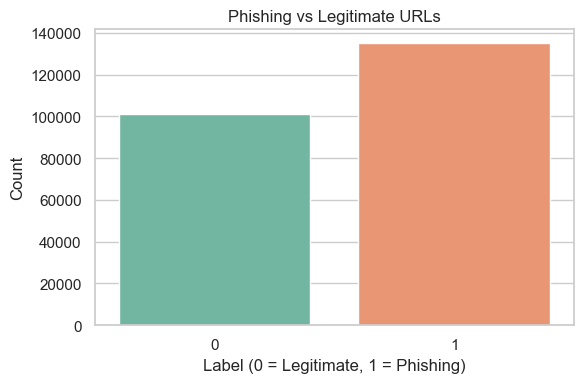

In [4]:
target_col = "label"

print("\nTarget Distribution:")
print(df[target_col].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df, palette="Set2")
plt.title("Phishing vs Legitimate URLs")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


CELL 5 — Feature Type Detection

In [5]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()

# Remove target from numerical list
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)
print("Datetime columns:", datetime_cols)


Categorical columns: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
Numerical columns: ['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']
Datetime columns: []


CELL 6 — Numerical Summary

In [6]:
df[numerical_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


CELL 7 — Correlation Matrix

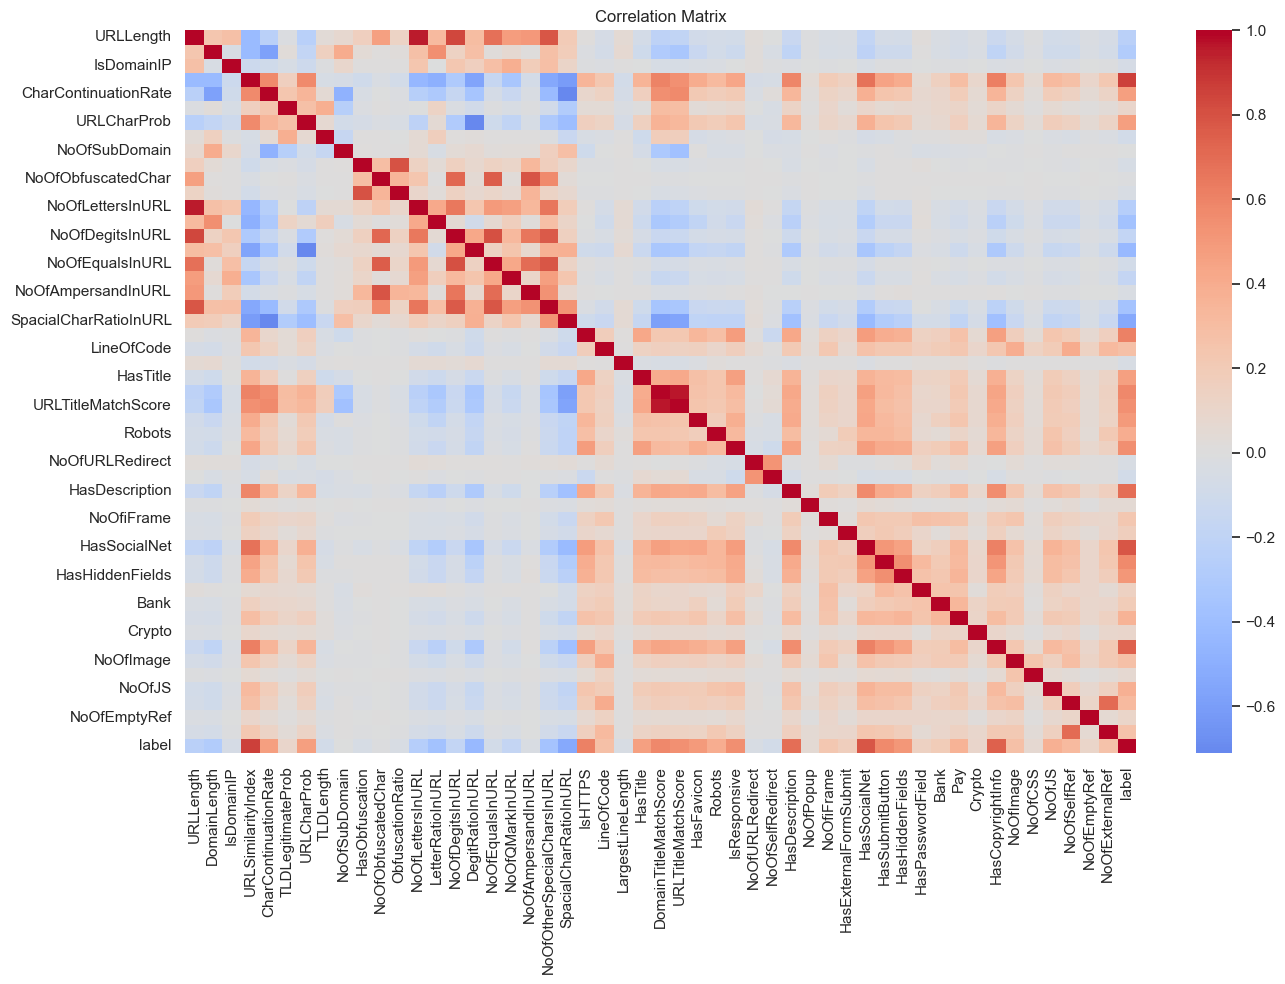

In [7]:
plt.figure(figsize=(14,10))
corr = df[numerical_cols + [target_col]].corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


CELL 8 — Top Correlated Features with Target

Top positively correlated features:
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
HasHiddenFields          0.507731
Name: label, dtype: float64

Top negatively correlated features:
TLDLength                    -0.079159
NoOfQMarkInURL               -0.175621
NoOfDegitsInURL              -0.177980
URLLength                    -0.233445
NoOfLettersInURL             -0.258090
DomainLength                 -0.283152
NoOfOtherSpecialCharsInURL   -0.358891
LetterRatioInURL             -0.367794
DegitRatioInURL              -0.432032
SpacialCharRatioInURL        -0.533537
Name: label, dtype: float64


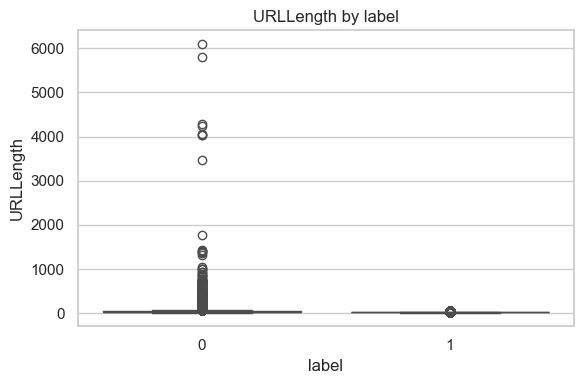

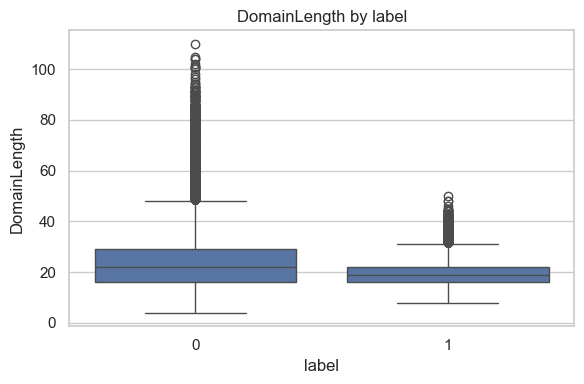

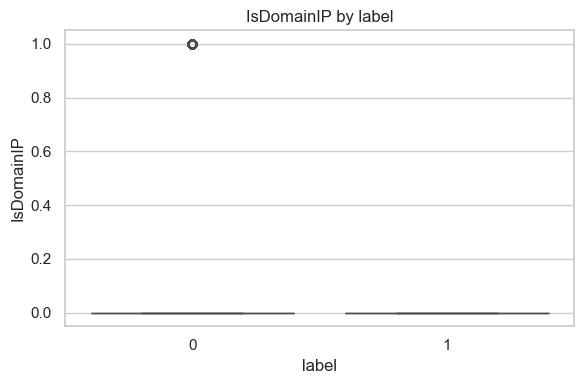

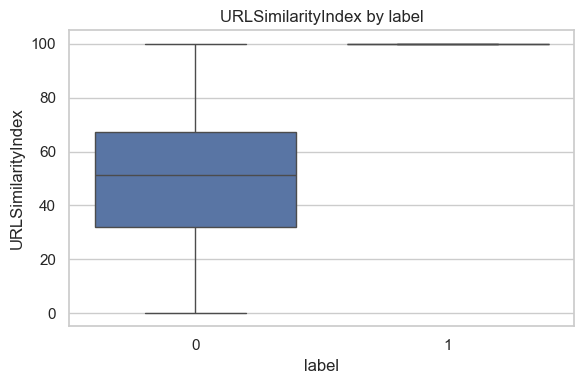

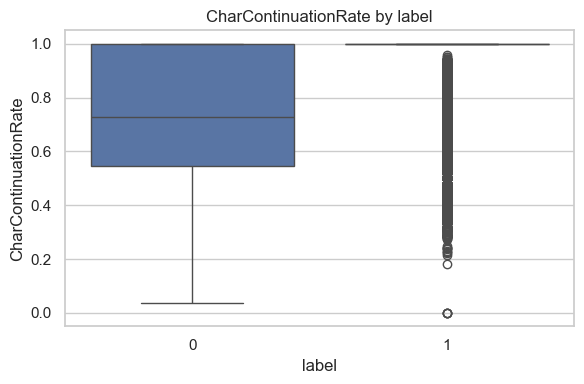

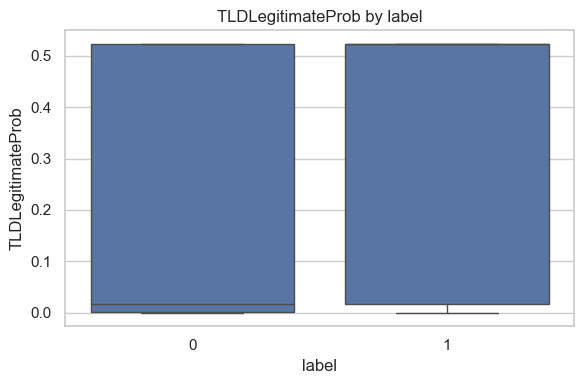

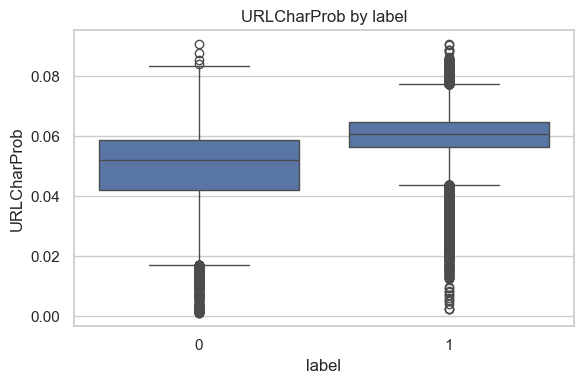

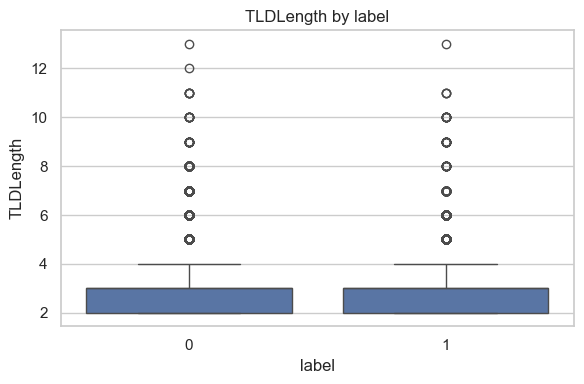

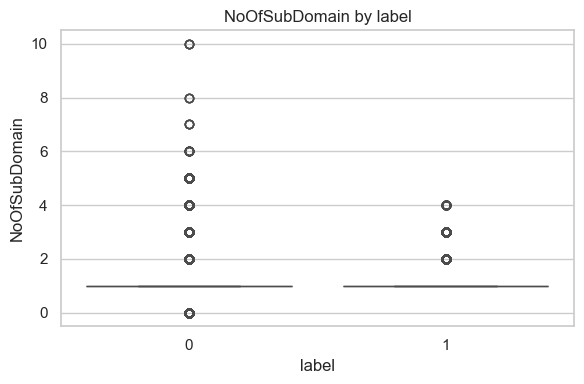

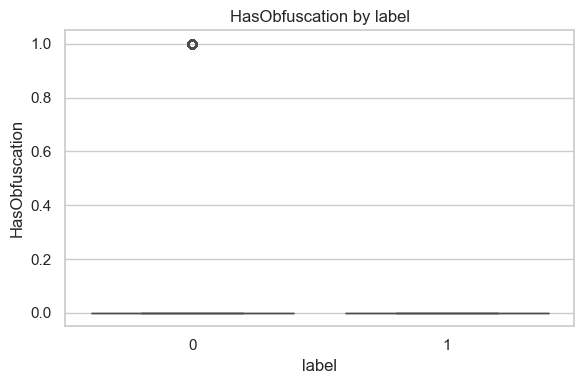

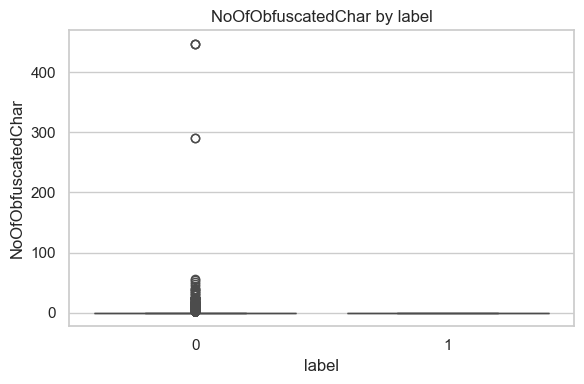

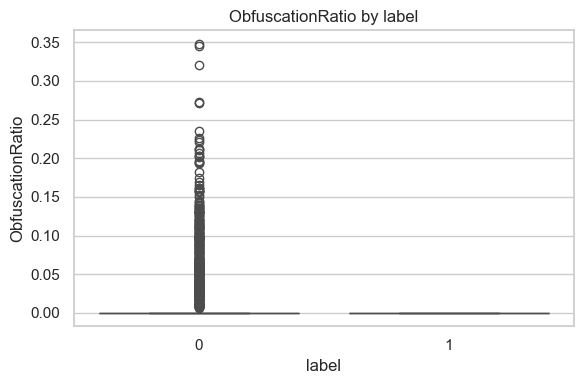

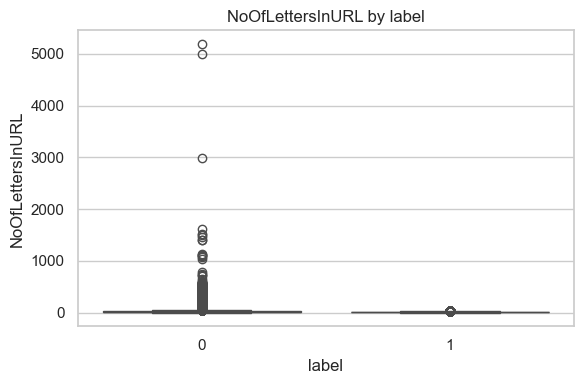

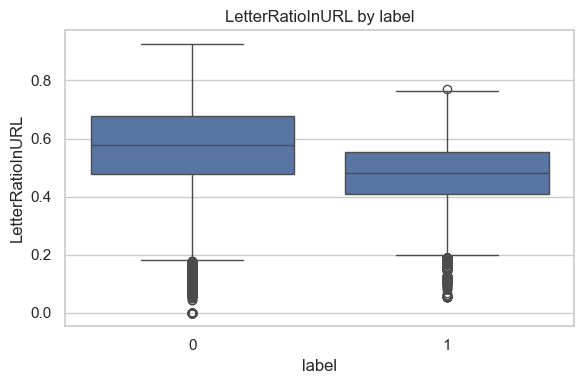

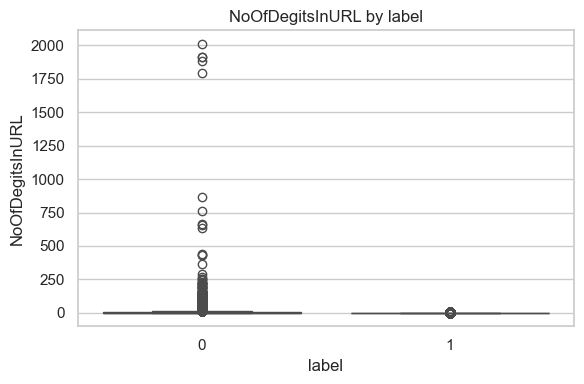

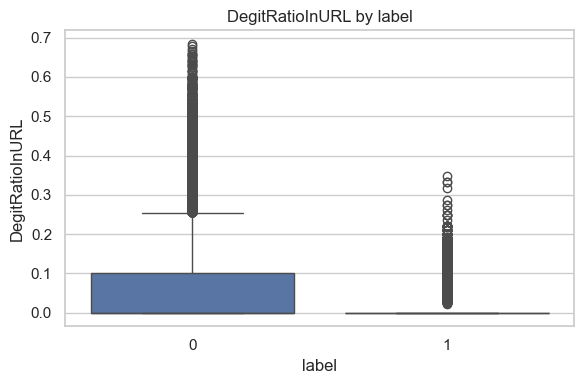

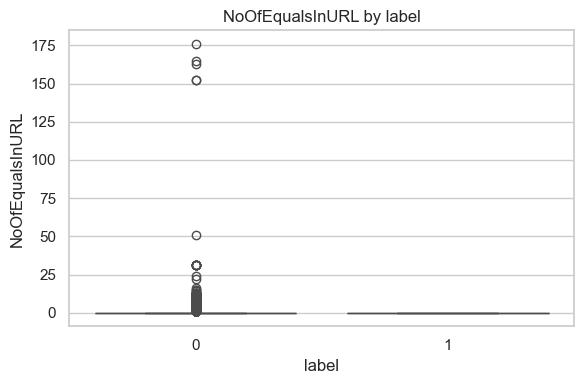

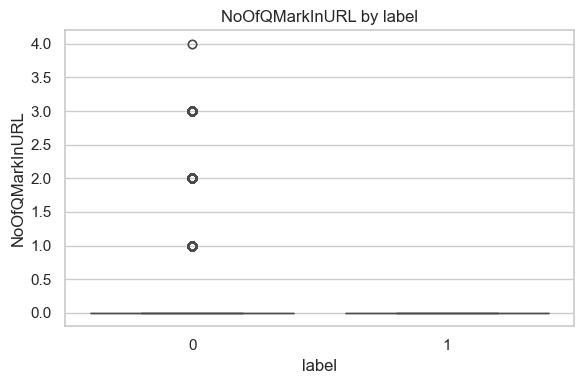

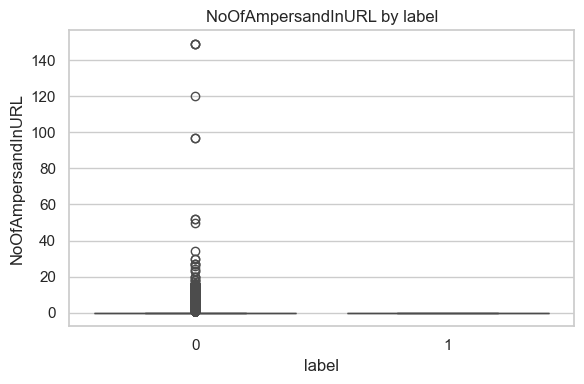

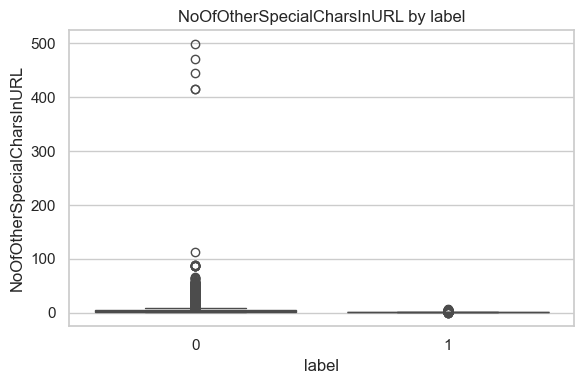

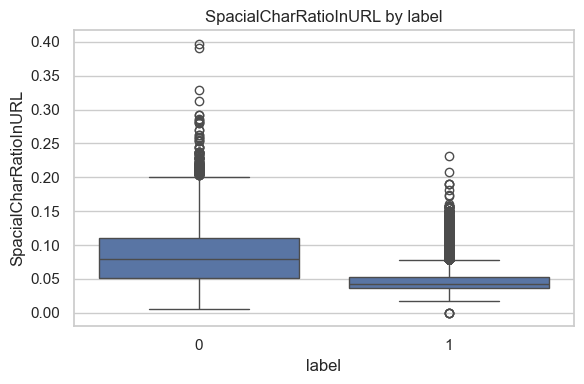

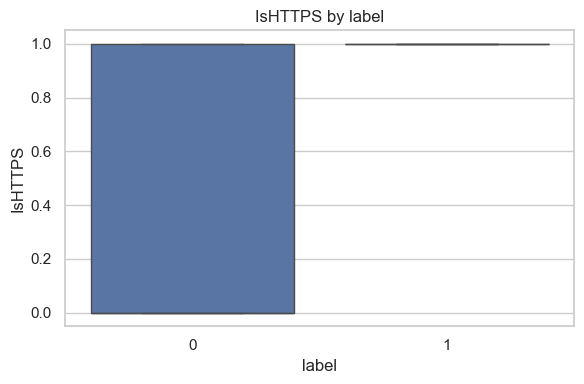

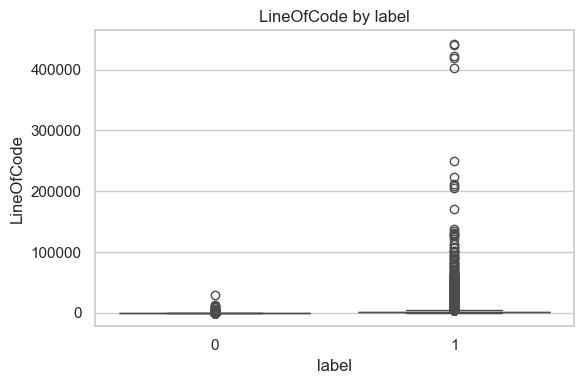

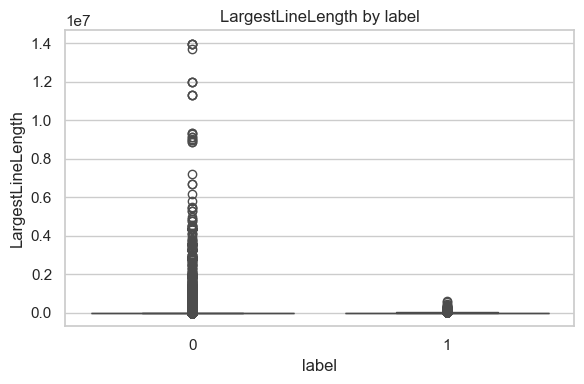

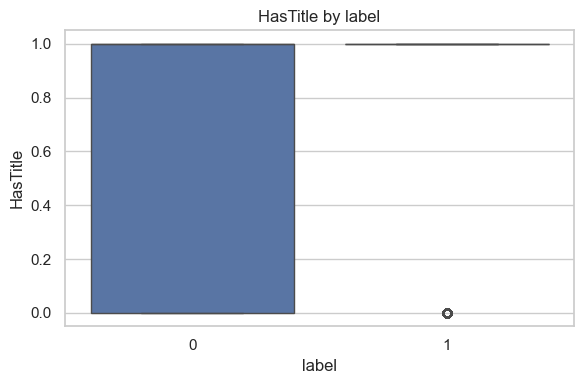

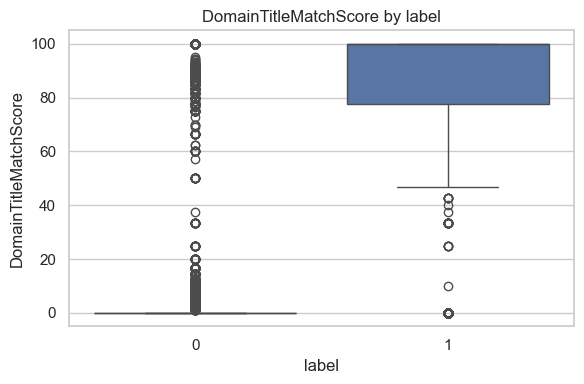

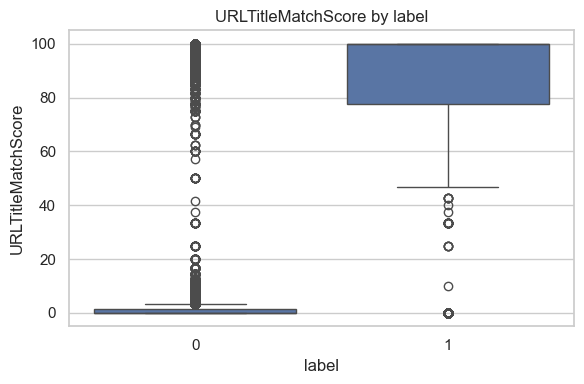

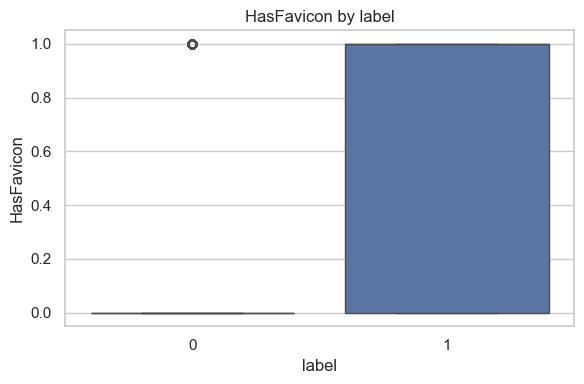

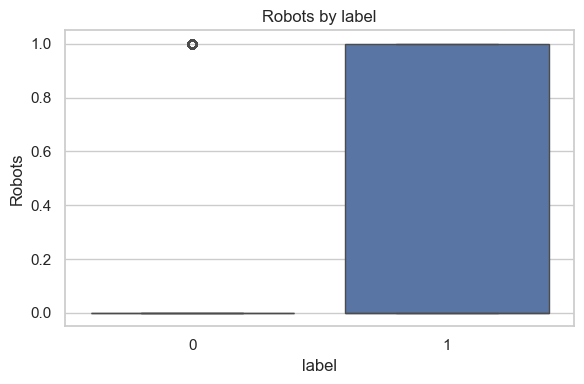

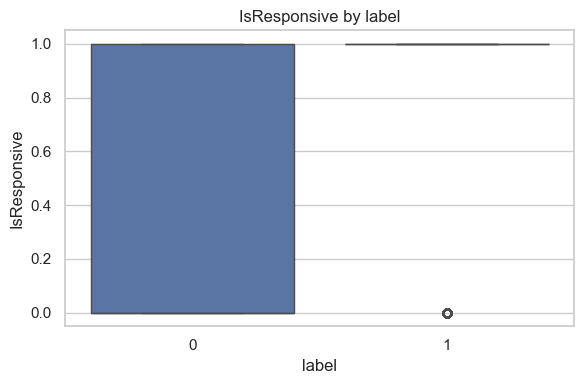

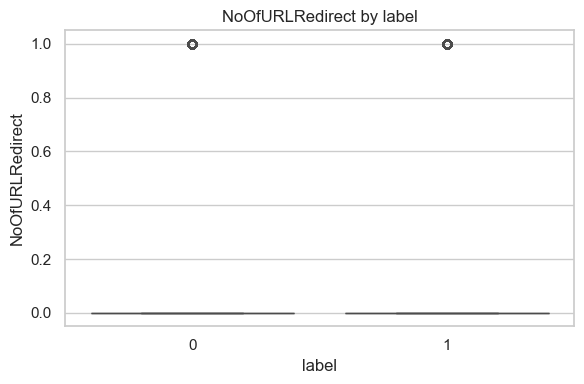

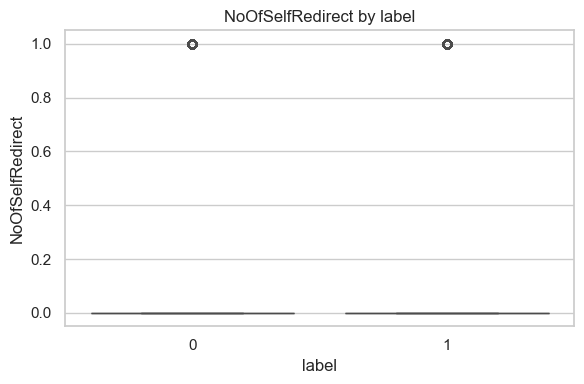

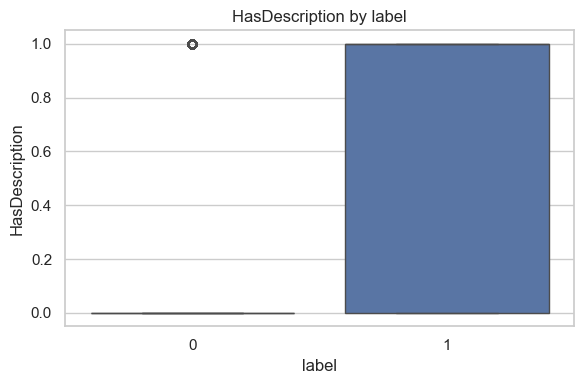

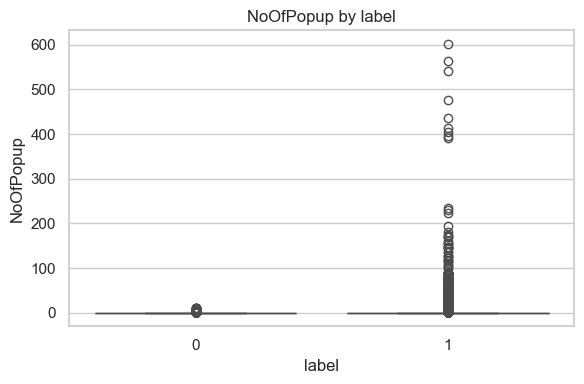

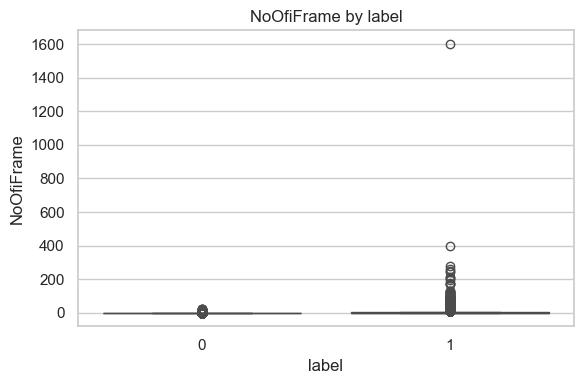

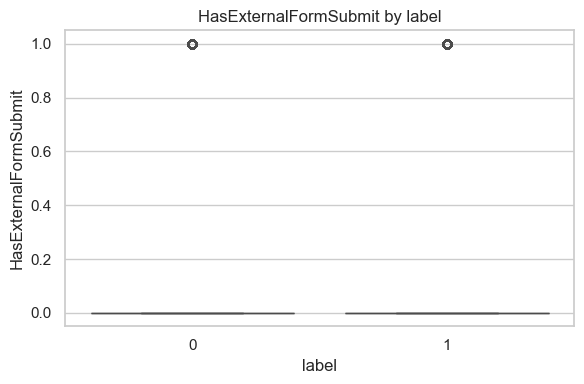

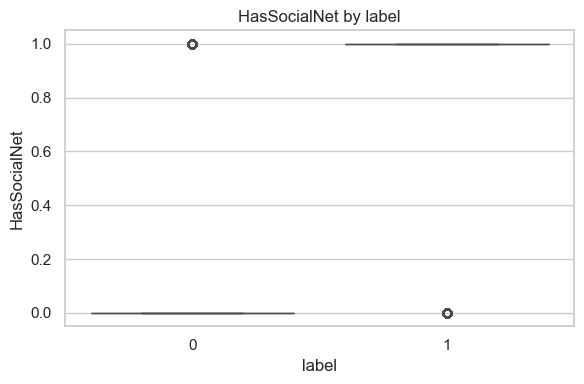

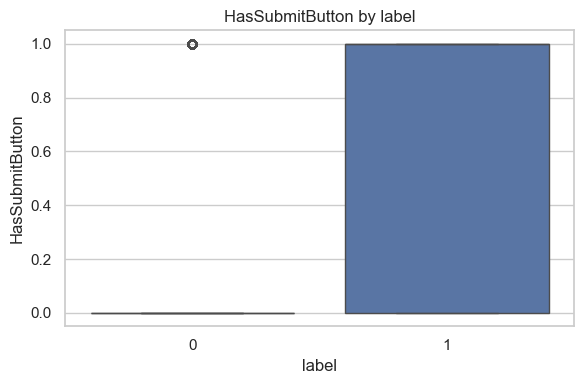

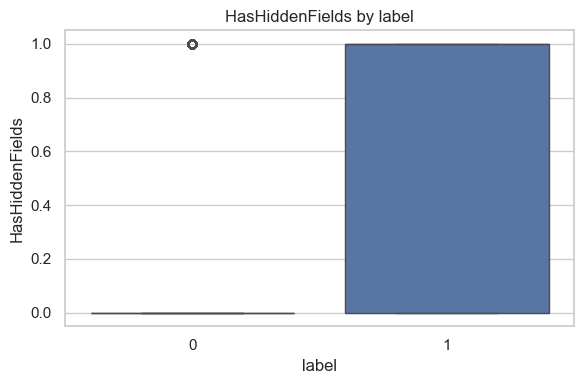

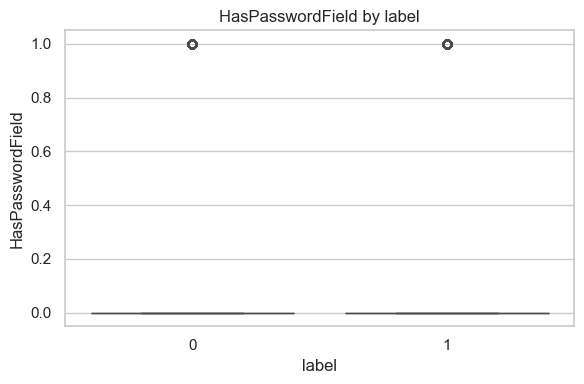

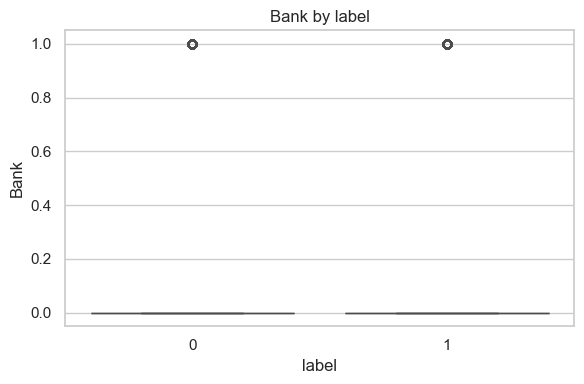

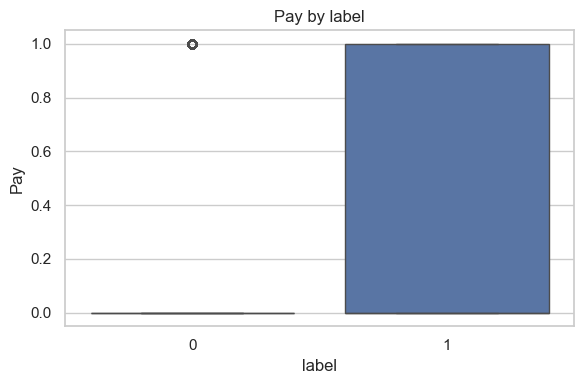

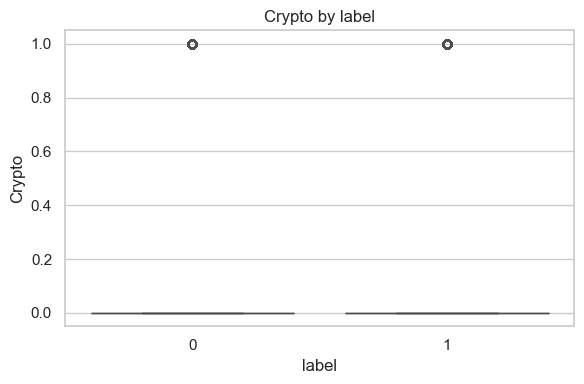

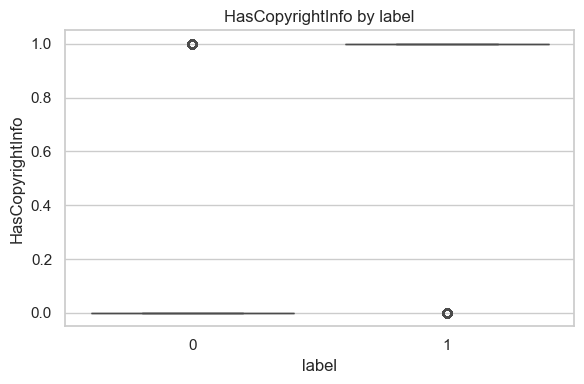

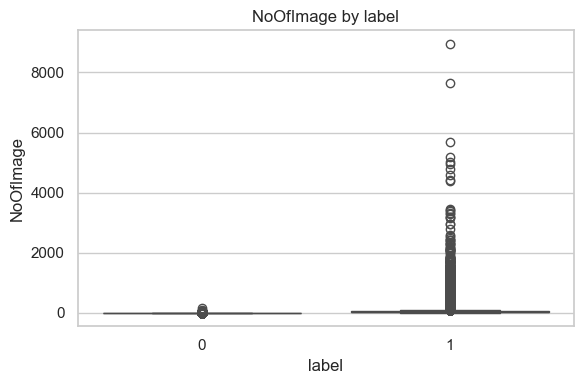

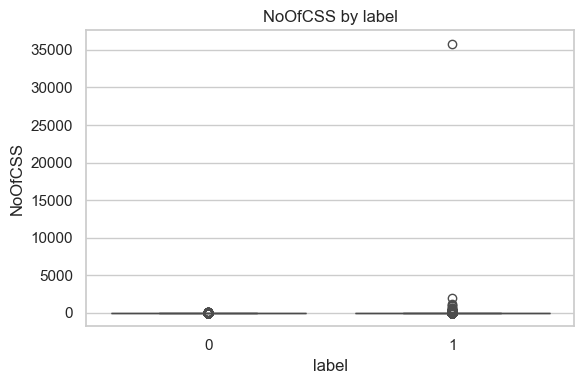

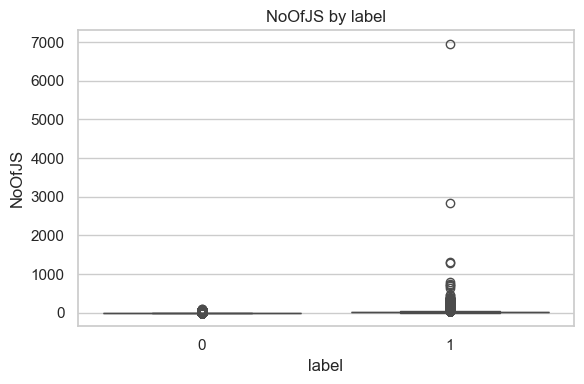

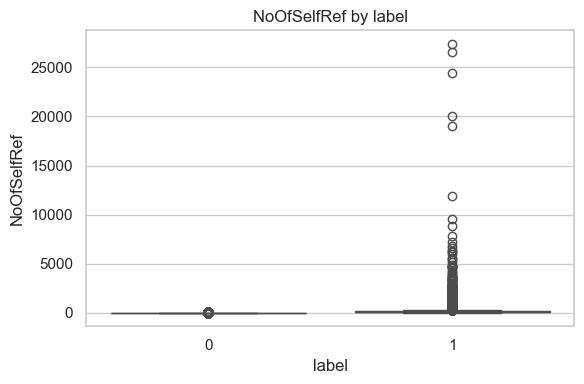

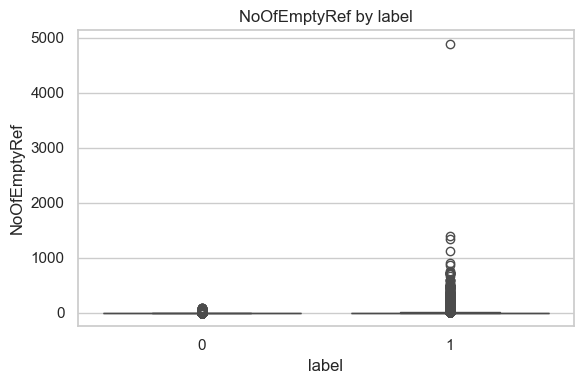

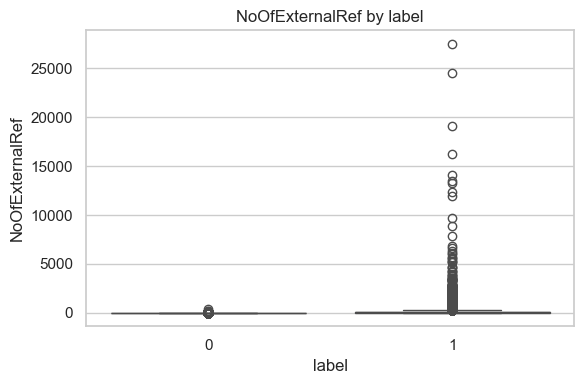

In [8]:
target_corr = corr[target_col].drop(target_col).sort_values(ascending=False)

print("Top positively correlated features:")
print(target_corr.head(10))

print("\nTop negatively correlated features:")
print(target_corr.tail(10))
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"{col} by {target_col}")
    plt.tight_layout()
    plt.show()

CELL 9 — Distribution Plots for Key Features

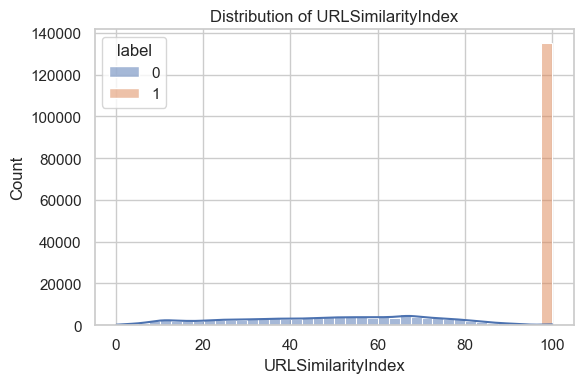

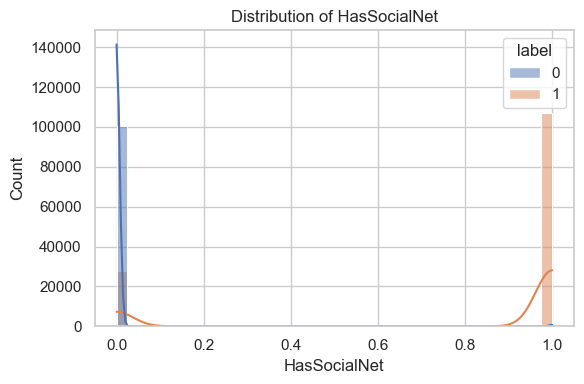

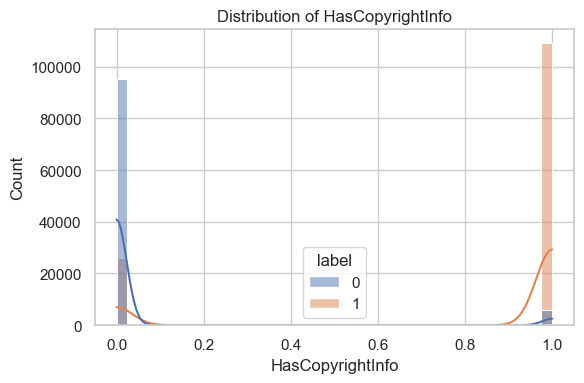

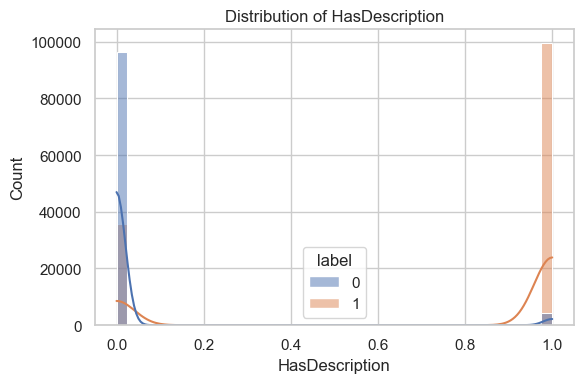

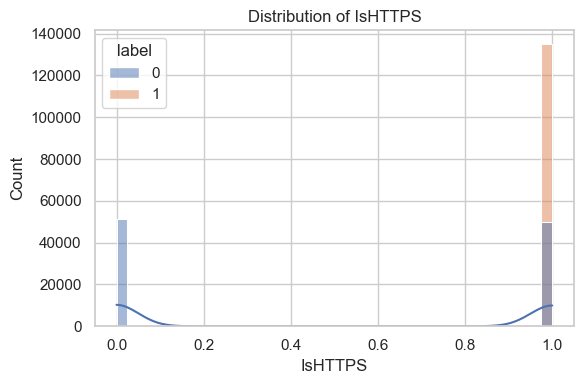

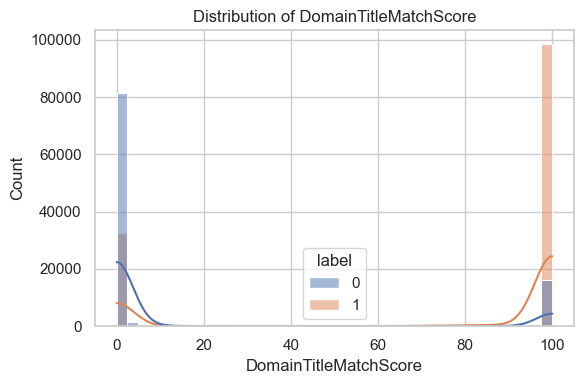

In [9]:
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

for col in top_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue=target_col, bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


CELL 10 — Boxplots for Outlier Detection

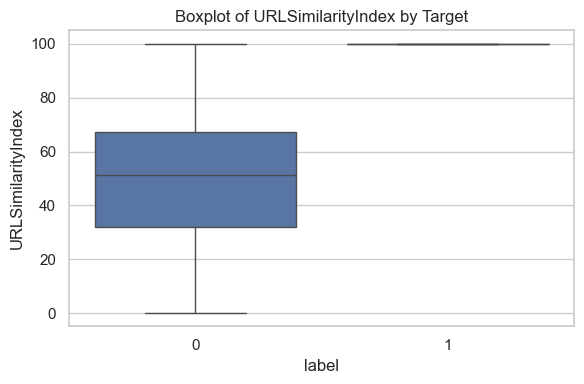

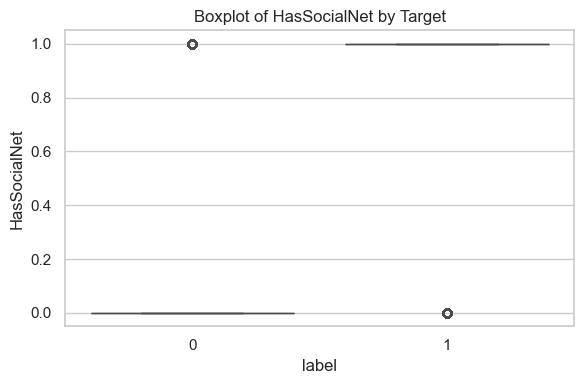

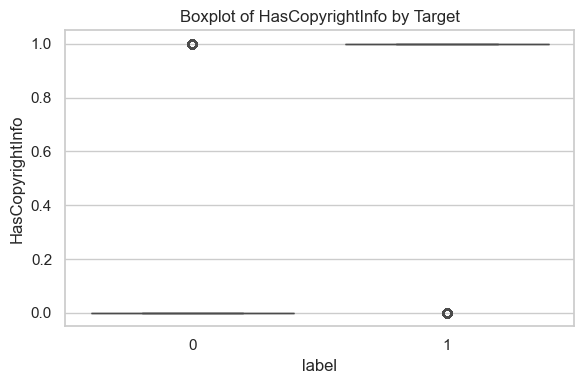

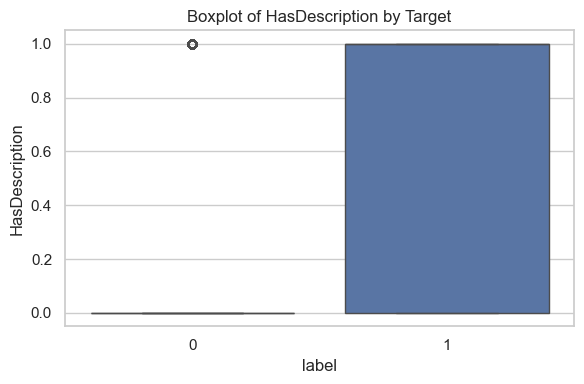

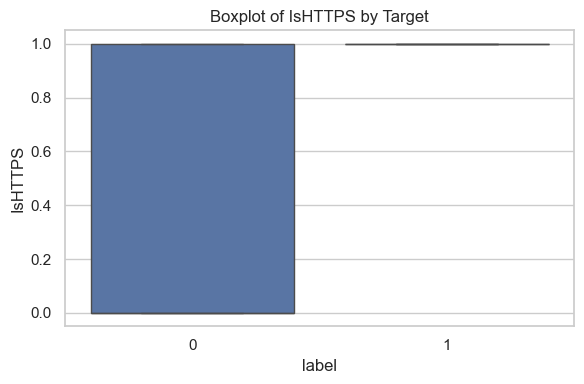

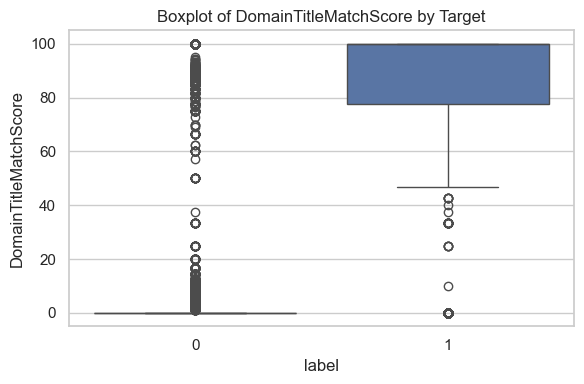

In [10]:
for col in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"Boxplot of {col} by Target")
    plt.tight_layout()
    plt.show()


CELL 11 — Categorical Feature Analysis

In [11]:
for col in categorical_cols:
    if col != target_col:
        print(f"\nTop categories in {col}:")
        print(df[col].value_counts().head(10))



Top categories in FILENAME:
FILENAME
521848.txt      1
96605.txt       1
oph08639.txt    1
8024072.txt     1
8014599.txt     1
439573.txt      1
492386.txt      1
7957102.txt     1
785434.txt      1
499340.txt      1
Name: count, dtype: int64

Top categories in URL:
URL
https://disclosepack.myportfolio.com/                                                                                         2
https://barlandas.com/reprisedefunction/unzupdm/                                                                              2
http://app-batasotak1244acces.kvoiffugw9-yk26ed5vg379.p.temp-site.link/termsofservice.html                                    2
https://fleek.ipfs.io/ipfs/qmzt2xz7uq7tdgiirmv7u7zaabtfhjn8jzouurbptgtgal/                                                    2
https://sucursalvirtualpersona.la-empresaempre.repl.co/                                                                       2
https://owashdy.web.app/                                                                

CELL 12 — Missing Value Heatmap

In [12]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()


MemoryError: Unable to allocate 403. MiB for an array with shape (235795, 56, 4) and data type float64

<Figure size 1200x600 with 1 Axes>

CELL 13 — Feature Importance (Quick Baseline Model)

Top 15 important features:
URLSimilarityIndex            0.211292
URL                           0.117622
NoOfExternalRef               0.111637
NoOfJS                        0.104681
NoOfSelfRef                   0.082565
LineOfCode                    0.064333
FILENAME                      0.047146
HasCopyrightInfo              0.041344
NoOfImage                     0.038189
Domain                        0.032345
NoOfCSS                       0.028025
HasSocialNet                  0.021358
HasDescription                0.015724
LargestLineLength             0.012410
NoOfOtherSpecialCharsInURL    0.006860
dtype: float64


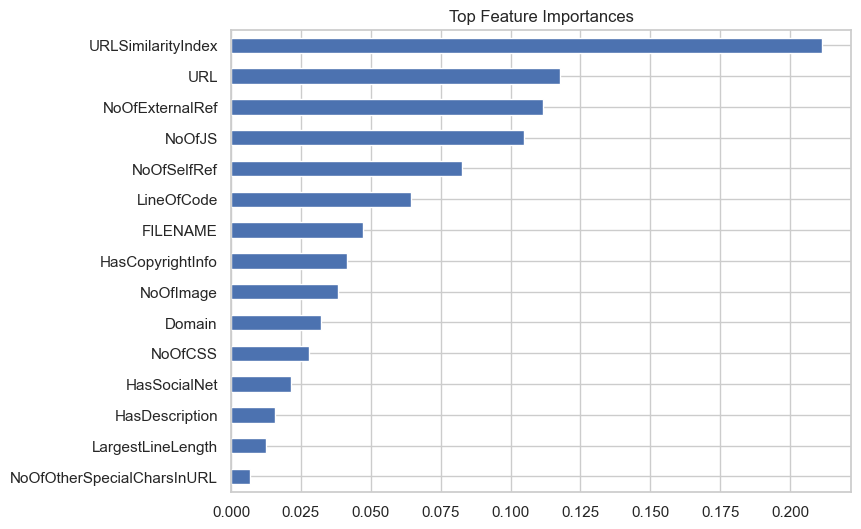

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Copy data
model_df = df.copy()

# Encode categoricals
for col in categorical_cols:
    if col != target_col:
        le = LabelEncoder()
        model_df[col] = le.fit_transform(model_df[col].astype(str))

X = model_df.drop(columns=[target_col])
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("Top 15 important features:")
print(importances.head(15))

plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()


CELL 14 — Save Cleaned Dataset for Modeling

In [16]:
output_path = "../data/clean/cleaned_dataset.csv"
df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to {output_path}")


Cleaned dataset saved to ../data/clean/cleaned_dataset.csv
